# 01 — Audio basics

What does the audio actually look like? Waveform, spectrogram, chroma, onsets. Everything downstream is judged against what you see here.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "tests").exists():
    ROOT = ROOT.parent
AUDIO_DIR = ROOT / "tests" / "fixtures" / "audio"
GOLDEN_DIR = ROOT / "tests" / "fixtures" / "golden"
print("project root:", ROOT)


project root: /home/anton/Projects/music-teacher


In [2]:
from music_teacher.transcription.audio import load_audio
import librosa
import librosa.display

path = AUDIO_DIR / "flute_melody.wav"
audio = load_audio(path)
sr = 22050
print(f"{path.name}: {audio.shape[0]} samples ({audio.shape[0] / sr:.2f}s)")


flute_melody.wav: 82908 samples (3.76s)


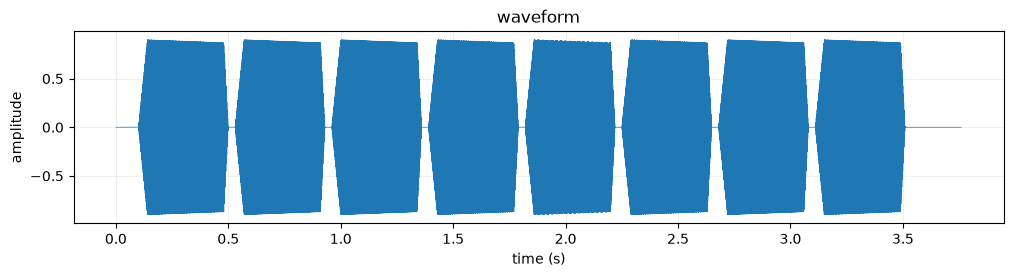

In [3]:
fig, ax = plt.subplots(figsize=(12, 2.5))
times = np.arange(audio.shape[0]) / sr
ax.plot(times, audio, linewidth=0.5)
ax.set(title="waveform", xlabel="time (s)", ylabel="amplitude"); ax.grid(alpha=.2)


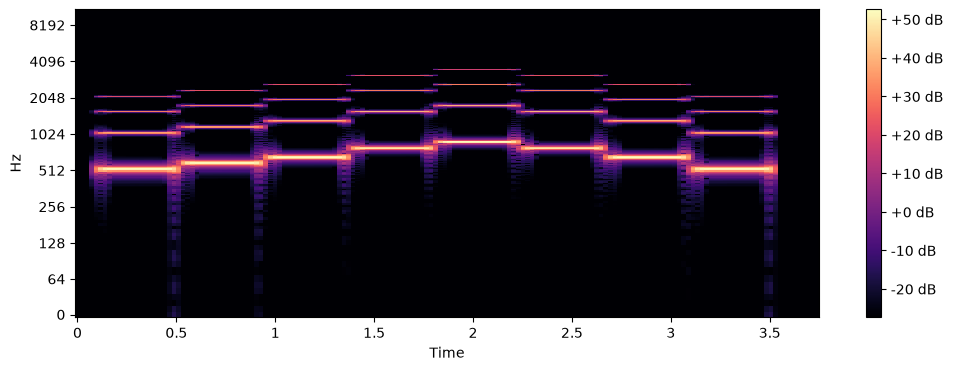

In [4]:
spectrum = librosa.amplitude_to_db(np.abs(librosa.stft(audio.astype(float), n_fft=2048, hop_length=512)), ref=1.0)
fig, ax = plt.subplots(figsize=(12, 4))
img = librosa.display.specshow(spectrum, sr=sr, hop_length=512, x_axis="time", y_axis="log", ax=ax, cmap="magma")
fig.colorbar(img, ax=ax, format="%+2.0f dB")


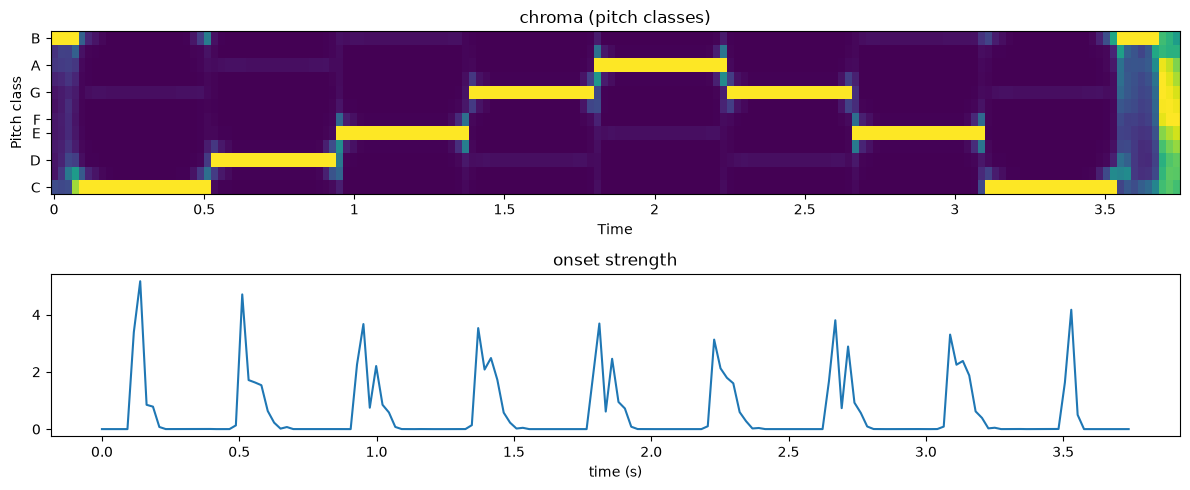

In [5]:
chroma = librosa.feature.chroma_cqt(y=audio.astype(float), sr=sr)
onset_env = librosa.onset.onset_strength(y=audio.astype(float), sr=sr, hop_length=512)
fig, (a, b) = plt.subplots(2, 1, figsize=(12, 5))
librosa.display.specshow(chroma, sr=sr, hop_length=512, x_axis="time", y_axis="chroma", ax=a, cmap="viridis")
a.set_title("chroma (pitch classes)")
b.plot(librosa.frames_to_time(np.arange(len(onset_env)), sr=sr, hop_length=512), onset_env)
b.set(title="onset strength", xlabel="time (s)")
fig.tight_layout()


**Try it:** swap in `flute_noisy.wav` or your own recording and compare. Notice which harmonics dominate — that is what confuses the transcriber.